# Entrenamiento de EfficientNet-B4

Este notebook entrena un clasificador binario (real vs. deepfake) usando fine-tuning de **EfficientNet-B4** sobre FaceForensics++, como comparación con Xception (ver `03a_train_xception.ipynb`).

Mismo dataset, mismo split y misma configuración de entrenamiento que Xception, para que la comparación entre arquitecturas sea válida.

## 1. Dependencias y configuración

In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'timm', 'albumentations',
    'matplotlib', 'seaborn', 'pandas', 'scikit-learn',
    'opencv-python', 'tqdm'])


0

In [2]:
from pathlib import Path
import torch
import torch.nn as nn
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

from src.config import make_config, set_seed
from src.data import build_frame_dataframe, make_loaders
from src.models import build_model, build_optimizer
from src.engine import train_model, evaluate_test
from src.viz import plot_history

In [3]:
CONFIG = make_config(MODEL_NAME='efficientnet_b4')
set_seed(CONFIG['SEED'])
print(f"Device: {CONFIG['DEVICE']}")
CONFIG

Device: cuda


{'DATA_DIR': PosixPath('/home/ramoss/dataset_split'),
 'OUTPUT_DIR': PosixPath('/home/ramoss/outputs'),
 'SEED': 42,
 'IMG_SIZE': 299,
 'BATCH_SIZE': 32,
 'LR': 0.0001,
 'LR_HEAD': 0.001,
 'WEIGHT_DECAY': 0.0001,
 'EPOCHS': 15,
 'PATIENCE': 5,
 'DROPOUT': 0.3,
 'NUM_WORKERS': 4,
 'DEVICE': 'cuda',
 'MODEL_NAME': 'efficientnet_b4'}

## 2. Dataset y DataLoaders

In [4]:
df = build_frame_dataframe(CONFIG['DATA_DIR'])
print(f'Total frames: {len(df):,}')
print(df.groupby(['split', 'label']).size().unstack(fill_value=0))

Total frames: 60,000
label     0      1
split             
test   1400   7000
train  7200  36000
val    1400   7000


In [5]:
train_loader, val_loader, test_loader = make_loaders(df, CONFIG)

Train: 43,200 | Val: 8,400 | Test: 8,400


## 3. Definición del modelo

Fine-tuning completo de EfficientNet-B4 con dropout (0.3) y learning rate diferenciada: mayor para la capa de clasificación final, menor para el resto del backbone. Misma configuración que Xception para que la comparación sea válida.

In [6]:
model = build_model(CONFIG['MODEL_NAME'], CONFIG['DEVICE'], dropout=CONFIG['DROPOUT'])
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
optimizer = build_optimizer(model, CONFIG['LR'], CONFIG['LR_HEAD'], CONFIG['WEIGHT_DECAY'])
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['EPOCHS'], eta_min=1e-6
)

efficientnet_b4 — parámetros entrenables: 17,550,409


## 4. Loop de entrenamiento

In [7]:
print('Entrenando EfficientNet-B4')
history_efficientnet = train_model(
    model, 'efficientnet_b4', train_loader, val_loader,
    optimizer, criterion, scheduler, CONFIG
)

Entrenando EfficientNet-B4


Epoch 01/15 | train_loss=0.7849 train_acc=0.5655 | val_loss=0.6506 val_acc=0.6385 val_auc=0.6763  ✓ checkpoint guardado (AUC=0.6763)


Epoch 02/15 | train_loss=0.5751 train_acc=0.6789 | val_loss=0.5814 val_acc=0.7167 val_auc=0.7419  ✓ checkpoint guardado (AUC=0.7419)


Epoch 03/15 | train_loss=0.4670 train_acc=0.7515 | val_loss=0.5959 val_acc=0.7462 val_auc=0.7627  ✓ checkpoint guardado (AUC=0.7627)


Epoch 04/15 | train_loss=0.3931 train_acc=0.7933 | val_loss=0.6284 val_acc=0.7515 val_auc=0.7788  ✓ checkpoint guardado (AUC=0.7788)


...

Epoch 10/15 | train_loss=0.2154 train_acc=0.8808 | val_loss=0.9199 val_acc=0.8038 val_auc=0.7873  (sin mejora 1/5)


Epoch 11/15 | train_loss=0.2055 train_acc=0.8834 | val_loss=0.9145 val_acc=0.7956 val_auc=0.7884  (sin mejora 2/5)


Epoch 12/15 | train_loss=0.1975 train_acc=0.8894 | val_loss=0.9371 val_acc=0.8094 val_auc=0.7906  (sin mejora 3/5)


Epoch 13/15 | train_loss=0.1933 train_acc=0.8909 | val_loss=0.9338 val_acc=0.8093 val_auc=0.7906  (sin mejora 4/5)


Epoch 14/15 | train_loss=0.1881 train_acc=0.8933 | val_loss=0.9989 val_acc=0.8138 val_auc=0.7846  (sin mejora 5/5)

Early stopping en época 14.


## 5. Curvas de entrenamiento

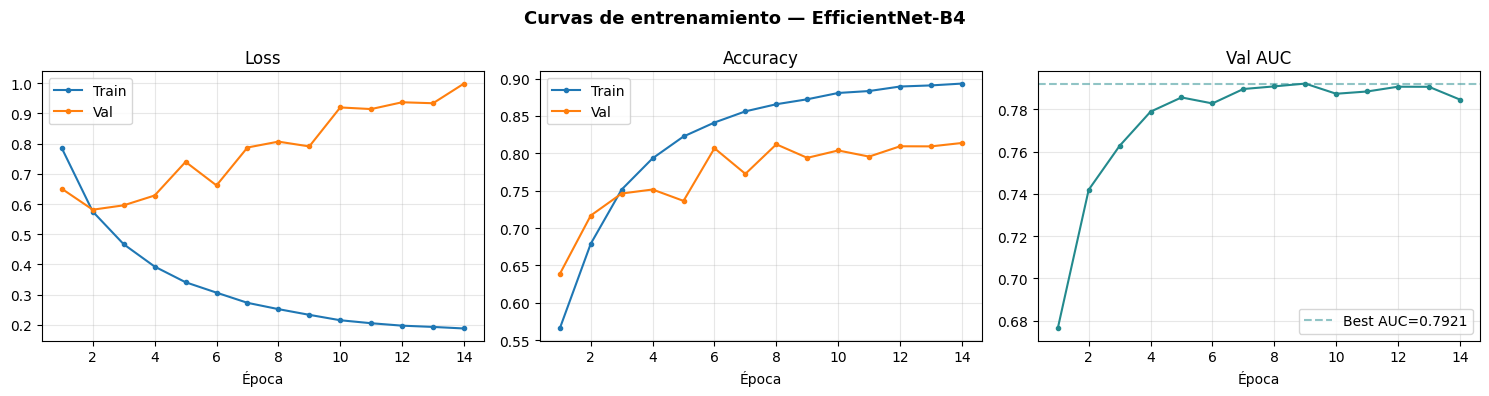

    epoch  train_loss  train_acc  val_loss   val_acc   val_auc
4       5    0.341201   0.822523  0.739721  0.736310  0.785564
5       6    0.306798   0.841204  0.661746  0.806786  0.782730
6       7    0.273067   0.856157  0.787230  0.772500  0.789543
7       8    0.252187   0.865694  0.806742  0.812024  0.790790
8       9    0.233290   0.872315  0.790870  0.793929  0.792115
9      10    0.215402   0.880764  0.919888  0.803810  0.787303
10     11    0.205514   0.883356  0.914545  0.795595  0.788374
11     12    0.197451   0.889398  0.937052  0.809405  0.790635
12     13    0.193265   0.890880  0.933824  0.809286  0.790589
13     14    0.188130   0.893333  0.998920  0.813810  0.784561


In [8]:
plot_history(history_efficientnet, 'EfficientNet-B4', CONFIG['OUTPUT_DIR'])
history_efficientnet.to_csv(CONFIG['OUTPUT_DIR'] / 'history_efficientnet_b4.csv', index=False)
print(history_efficientnet.tail(10))

## 6. Evaluación en test set

Test: 100%|██████████████████████████████████████████████████████████████████████████| 263/263 [00:32<00:00,  8.14it/s]



── efficientnet_b4 — Test AUC: 0.7996 ──
              precision    recall  f1-score   support

        real       0.45      0.55      0.49      1400
        fake       0.91      0.86      0.88      7000

    accuracy                           0.81      8400
   macro avg       0.68      0.71      0.69      8400
weighted avg       0.83      0.81      0.82      8400



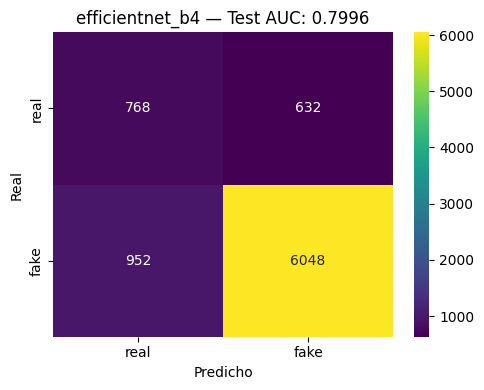

In [9]:
auc_efficientnet, preds_efficientnet, targets_test, probs_efficientnet = evaluate_test(
    model, 'efficientnet_b4', test_loader, CONFIG['DEVICE'], CONFIG['OUTPUT_DIR']
)

## 7. Resumen de resultados

In [10]:
results_eff = pd.DataFrame([{
    'Modelo': 'EfficientNet-B4',
    'AUC-ROC (test)': round(auc_efficientnet, 4),
    'Accuracy (test)': round(accuracy_score(targets_test, preds_efficientnet), 4),
    'F1 (fake)': round(f1_score(targets_test, preds_efficientnet), 4),
    'Best Val AUC': round(history_efficientnet['val_auc'].max(), 4),
    'Épocas entrenadas': len(history_efficientnet),
    'Parámetros': f'{total_params:,}',
}])

print(results_eff.to_string(index=False))
results_eff.to_csv(CONFIG['OUTPUT_DIR'] / 'results_efficientnet_b4.csv', index=False)

         Modelo  AUC-ROC (test)  Accuracy (test)  F1 (fake)  Best Val AUC  Épocas entrenadas Parámetros
EfficientNet-B4          0.7996           0.8114     0.8842        0.7921                 14 17,550,409


## 8. Comparación con Xception


In [11]:
xception_csv = CONFIG['OUTPUT_DIR'] / 'results_xception.csv'
if not xception_csv.exists():
    print(f'[!] No se encontró {xception_csv}. Corré 03a primero (con la celda de guardado agregada).')
else:
    results_xception = pd.read_csv(xception_csv)
    results = pd.concat([results_xception, results_eff.rename(columns={'AUC-ROC (test)': 'AUC-ROC'})],
                         ignore_index=True)
    print('\nComparación de arquitecturas:')
    print(results.to_string(index=False))
    results.to_csv(CONFIG['OUTPUT_DIR'] / 'comparison_table.csv', index=False)


Comparación de arquitecturas:
         Modelo  AUC-ROC (test)  Accuracy (test)  F1 (fake)  Best Val AUC  Épocas entrenadas  AUC-ROC Parámetros
       Xception          0.8237           0.8283     0.8961        0.8222                 11      NaN        NaN
EfficientNet-B4             NaN           0.8114     0.8842        0.7921                 14   0.7996 17,550,409
